# Object Detection on Images with YOLO (darkflow)

`darkflow` is a TensorFlow **1.x** port of darknet/YOLO, so it needs three
one-time fixes to run on this TF 2.19 environment. They are already applied to
the vendored copy in `darkflow/`:

1. `import tensorflow as tf` -> `import tensorflow.compat.v1 as tf` (darkflow
   builds an explicit graph with placeholders and a `Session`).
2. `tf.contrib.slim` was removed in TF 2, and the standalone `tf_slim` package
   no longer imports on TF >= 2.16. darkflow only uses `slim.batch_norm` and
   `slim.flatten`, so both live in `darkflow/net/ops/slim_compat.py` now.
3. `np.memmap(..., shape=())` with a sub-array dtype no longer unpacks in modern
   NumPy, which broke the `.weights` reader in `darkflow/utils/loader.py`.

The Cython extensions (box finding + NMS) also have to be compiled once:

```bash
cd darkflow && ../.venv/bin/python setup.py build_ext --inplace
```


In [1]:
import os
import sys

# darkflow is vendored (not pip-installed), so put its repo root on sys.path.
darkflow_path = os.path.abspath('./darkflow')
if darkflow_path not in sys.path:
    sys.path.insert(0, darkflow_path)

# darkflow's sources are patched in place for TF2/NumPy 2 (see above). If this
# kernel imported an older copy, Python would keep serving it from memory and
# the *old* error would resurface under the *new* source lines. Drop it first.
for _mod in [m for m in sys.modules if m == 'darkflow' or m.startswith('darkflow.')]:
    del sys.modules[_mod]

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')  # darkflow is chatty enough

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from darkflow.net.build import TFNet

%config InlineBackend.figure_format = 'svg'

print('TensorFlow:', tf.__version__)
print('OpenCV    :', cv2.__version__)
print('darkflow  :', darkflow_path)

TensorFlow: 2.19.1
OpenCV    : 5.0.0
darkflow  : /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/darkflow


## Build the network

`config` must point at the directory holding `coco.names` -- darkflow defaults to
`./cfg/` relative to the *current* working directory, which is this notebook's
folder, not the darkflow repo.

In [2]:
options = {
    'model': 'resources/12.4 yolo/yolo.cfg',       # YOLOv2 (COCO, 80 classes)
    'load': 'resources/12.4 yolo/yolo.weights',
    'config': 'darkflow/cfg/',                     # where coco.names lives
    'threshold': 0.3,
    'gpu': 0.0,                                    # darkflow's TF1 GPU path predates Metal
}

tfnet = TFNet(options)

Parsing darkflow/cfg/yolo.cfg
Parsing resources/12.4 yolo/yolo.cfg
Loading resources/12.4 yolo/yolo.weights ...
Successfully identified 203934260 bytes
Finished in 0.00760197639465332s
Model has a coco model name, loading coco labels.

Building net ...
Source | Train? | Layer description                | Output size
-------+--------+----------------------------------+---------------
       |        | input                            | (None, 608, 608, 3)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (None, 608, 608, 32)
 Load  |  Yep!  | maxp 2x2p0_2                     | (None, 304, 304, 32)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (None, 304, 304, 64)
 Load  |  Yep!  | maxp 2x2p0_2                     | (None, 152, 152, 64)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (None, 152, 152, 128)
 Load  |  Yep!  | conv 1x1p0_1  +bnorm  leaky      | (None, 152, 152, 64)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (None, 152, 152, 128)
 Load  |  Yep!  | max

I0000 00:00:1788700797.153935  119380 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1788700797.153957  119380 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (None, 19, 19, 1024)
 Load  |  Yep!  | conv 1x1p0_1  +bnorm  leaky      | (None, 19, 19, 512)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (None, 19, 19, 1024)
 Load  |  Yep!  | conv 1x1p0_1  +bnorm  leaky      | (None, 19, 19, 512)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (None, 19, 19, 1024)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (None, 19, 19, 1024)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (None, 19, 19, 1024)
 Load  |  Yep!  | concat [16]                      | (None, 38, 38, 512)
 Load  |  Yep!  | conv 1x1p0_1  +bnorm  leaky      | (None, 38, 38, 64)
Instructions for updating:
ksizes is deprecated, use sizes instead
 Load  |  Yep!  | local flatten 2x2                | (None, 19, 19, 256)
 Load  |  Yep!  | concat [27, 24]                  | (None, 19, 19, 1280)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (None, 19, 19, 1024)
 Load  |  Yep!  | conv 1x1p0_1    linear           

I0000 00:00:1788700797.948133  119380 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


Finished in 2.0836360454559326s



## Predict and draw the boxes

bicycle      0.848  {'x': 80, 'y': 114} -> {'x': 555, 'y': 466}
truck        0.800  {'x': 462, 'y': 81} -> {'x': 694, 'y': 167}
dog          0.769  {'x': 136, 'y': 214} -> {'x': 322, 'y': 539}


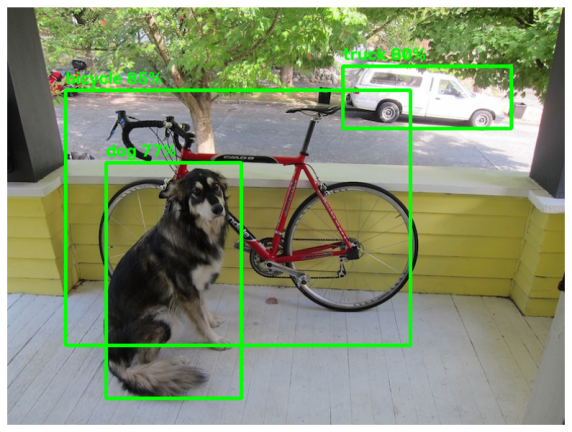

In [3]:
def detect(image_path, net=None, color=(0, 255, 0)):
    """Run YOLO on one image and return (annotated RGB image, predictions)."""
    net = net or tfnet
    bgr = cv2.imread(image_path)
    if bgr is None:
        raise FileNotFoundError(image_path)

    results = net.return_predict(bgr)
    out = bgr.copy()
    for r in results:
        tl = (r['topleft']['x'], r['topleft']['y'])
        br = (r['bottomright']['x'], r['bottomright']['y'])
        label = '{} {:.0%}'.format(r['label'], r['confidence'])
        cv2.rectangle(out, tl, br, color, 3)
        cv2.putText(out, label, (tl[0], max(tl[1] - 8, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    return cv2.cvtColor(out, cv2.COLOR_BGR2RGB), results


annotated, preds = detect('darkflow/sample_img/sample_dog.jpg')

for p in preds:
    print('{:12s} {:.3f}  {} -> {}'.format(
        p['label'], p['confidence'], p['topleft'], p['bottomright']))

plt.figure(figsize=(10, 8))
plt.imshow(annotated)
plt.axis('off')
plt.show()

## A few more sample images

In [4]:
samples = ['sample_office.jpg', 'sample_person.jpg',
           'sample_horses.jpg', 'sample_eagle.jpg']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, name in zip(axes.ravel(), samples):
    image, _ = detect(os.path.join('darkflow/sample_img', name))
    ax.imshow(image)
    ax.set_title(name)
    ax.axis('off')

plt.tight_layout()
plt.show()

#### Continuing the code as per the course video after second cell

In [7]:
img = cv2.imread('./darkflow/sample_img/sample_person.jpg', cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [8]:
img.shape

(424, 640, 3)

In [9]:
result = tfnet.return_predict(img)

In [10]:
result 

[{'label': 'person',
  'confidence': np.float32(0.83314914),
  'topleft': {'x': 187, 'y': 103},
  'bottomright': {'x': 271, 'y': 374}},
 {'label': 'dog',
  'confidence': np.float32(0.85182637),
  'topleft': {'x': 69, 'y': 259},
  'bottomright': {'x': 205, 'y': 354}},
 {'label': 'horse',
  'confidence': np.float32(0.87828165),
  'topleft': {'x': 397, 'y': 128},
  'bottomright': {'x': 606, 'y': 352}}]

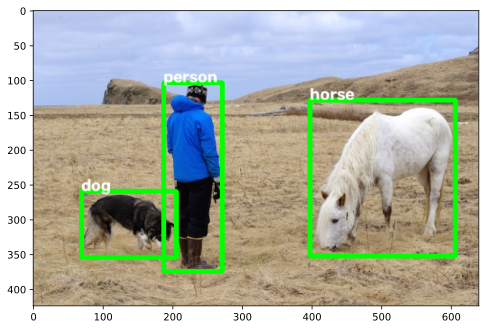

In [12]:
plt.figure(figsize=(8,12))
for r in result:
    tl = (r['topleft']['x'], r['topleft']['y'])
    br = (r['bottomright']['x'], r['bottomright']['y'])
    label = r['label']
    
    img = cv2.rectangle(img, tl, br, (0, 255, 0), 5)
    img = cv2.putText(img, label, tl, cv2.FONT_ITALIC, 0.8, (255, 255, 255), 2)

plt.imshow(img)
plt.show()

In [13]:
folder = './darkflow/sample_img/'

In [14]:
path = os.path.join(folder)

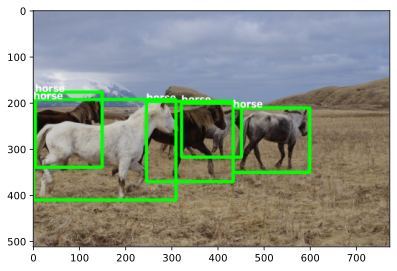

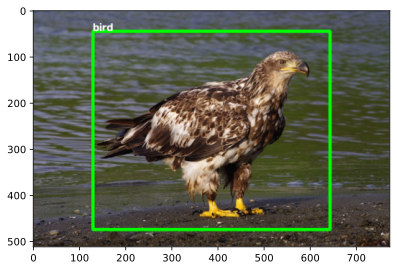

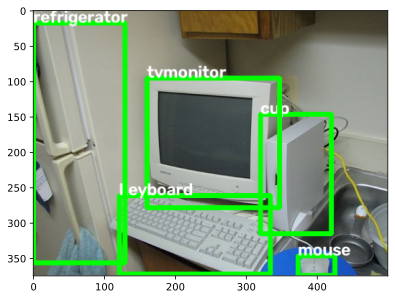

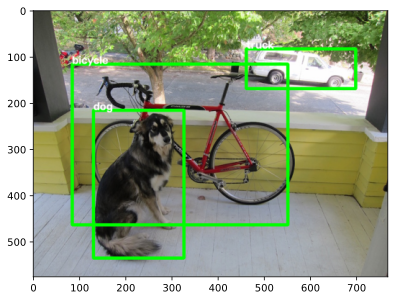

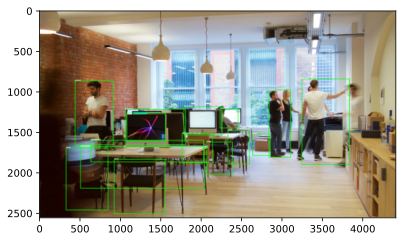

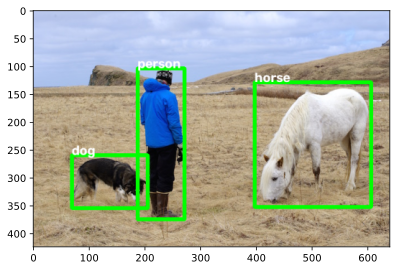

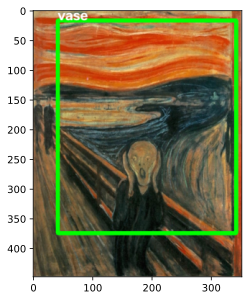

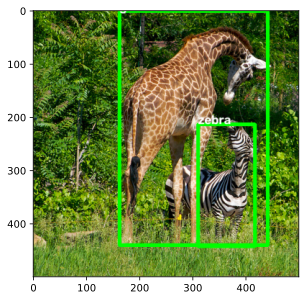

In [15]:
for image in os.listdir(path):
    img = cv2.imread(os.path.join(path,image), cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    result = tfnet.return_predict(img)
    
    for r in result:
        tl = (r['topleft']['x'], r['topleft']['y'])
        br = (r['bottomright']['x'], r['bottomright']['y'])
        label = r['label']
        img = cv2.rectangle(img, tl, br, (0, 255, 0), 6)
        #image, tof-left coordinates, bottom right coordinates, line color, thickness
        img = cv2.putText(img, label, tl, cv2.FONT_ITALIC, 0.8, (255, 255, 255), 2)
        #image, label, tof-left coordinates, font, font size, font color, linetype
    plt.imshow(img)
    plt.show()